# Partición de Grafos
## MA2015 - Diseño de Algoritmos Bioinspirados

Viviana Carrizales Luna (A01286191) & Steffany Mishell Lara Muy (A00838589)
*Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)*

**Resumen**
El presente proyecto tiene como finalidad desarrollar un algoritmo bioinspirado de partición de grafos para encontrar la solución óptima al problema de 16 grafos propuesto en clase.

### 1. Planteamiento del Problema

In [129]:
import pulp, time, random
import matplotlib.pyplot as plt


In [130]:

# Definición del grafo
V = list(range(1, 17))
E = [(1,2),(1,9),(1,14),(2,3),(2,5),(3,4),(3,5),(3,6),(3,7),(4,6),(5,7),(5,9),(5,10),
     (6,7),(6,8),(7,8),(7,11),(8,11),(9,10),(9,13),(9,14),(10,11),(10,12),(12,16),
     (13,15),(13,16),(14,15),(15,16)]


In [131]:
# Construir diccionario de adyacencia
def build_adj(edges):
    adj = {v: [] for v in V}
    for u, v in edges:
        adj[u].append(v)
        adj[v].append(u)
    return adj

# Calcular tamaño de corte (aristas que cruzan entre conjuntos)
def tam_corte(A, B, edges):
    return sum(1 for u, v in edges if (u in A and v in B) or (u in B and v in A))

# Obtener lista de aristas que cruzan entre conjuntos
def aristas_corte(A, B, edges):
    return [(u, v) for u, v in edges if (u in A and v in B) or (u in B and v in A)]

adj = build_adj(E)


### 2. Solución Exacta

In [132]:

#  SOLUCIÓN EXACTA (PuLP ILP) 

print(" SOLUCIÓN EXACTA (PuLP ILP) ")

t0 = time.time()
prob = pulp.LpProblem("ParticionGrafo", pulp.LpMinimize)
x = {i: pulp.LpVariable(f"x_{i}", cat='Binary') for i in V}
y = {(u,v): pulp.LpVariable(f"y_{u}_{v}", 0, 1) for u,v in E}

# Restricción de balance: exactamente 8 nodos en cada conjunto
prob += pulp.lpSum(x[i] for i in V) == 8
# Linealizar |x_u - x_v| para cada arista
for u, v in E:
    prob += y[(u,v)] >= x[u] - x[v]
    prob += y[(u,v)] >= x[v] - x[u]
# Objetivo: minimizar aristas de corte
prob += pulp.lpSum(y[(u,v)] for u,v in E)

prob.solve(pulp.PULP_CBC_CMD(msg=0))
t_exact = time.time() - t0

A_exact = sorted([i for i in V if pulp.value(x[i]) == 1])
B_exact = sorted([i for i in V if pulp.value(x[i]) == 0])
corte_exact = tam_corte(set(A_exact), set(B_exact), E)
aristas_cruzando_exact = aristas_corte(set(A_exact), set(B_exact), E)

print(f"Estado: {pulp.LpStatus[prob.status]}")
print(f"Conjunto A: {A_exact}")
print(f"Conjunto B: {B_exact}")
print(f"\n*** COSTO FINAL (aristas de corte): {corte_exact} ***")
print(f"Aristas que cruzan entre grupos: {aristas_cruzando_exact}")
print(f"Tiempo: {t_exact:.4f}s")

 SOLUCIÓN EXACTA (PuLP ILP) 
Estado: Optimal
Conjunto A: [1, 9, 10, 12, 13, 14, 15, 16]
Conjunto B: [2, 3, 4, 5, 6, 7, 8, 11]

*** COSTO FINAL (aristas de corte): 4 ***
Aristas que cruzan entre grupos: [(1, 2), (5, 9), (5, 10), (10, 11)]
Tiempo: 0.1409s


### 3. Solución con Partición de Grafos

In [133]:
#  HEURÍSTICA (Kernighan-Lin Manual) 

print(" HEURÍSTICA (Kernighan-Lin) ")

t0 = time.time()
random.seed(42)
nodes = V[:]
random.shuffle(nodes)
A, B = set(nodes[:8]), set(nodes[8:])


 HEURÍSTICA (Kernighan-Lin) 


In [134]:

# Mostrar partición inicial
corte_inicial = tam_corte(A, B, E)
aristas_inicial = aristas_corte(A, B, E)
print(f"\n--- PARTICIÓN INICIAL ---")
print(f"Conjunto A: {sorted(A)}")
print(f"Conjunto B: {sorted(B)}")
print(f"*** COSTO INICIAL: {corte_inicial} aristas cruzando ***")
print(f"Aristas que cruzan: {aristas_inicial}")



--- PARTICIÓN INICIAL ---
Conjunto A: [6, 7, 8, 9, 10, 11, 13, 15]
Conjunto B: [1, 2, 3, 4, 5, 12, 14, 16]
*** COSTO INICIAL: 12 aristas cruzando ***
Aristas que cruzan: [(1, 9), (3, 6), (3, 7), (4, 6), (5, 7), (5, 9), (5, 10), (9, 14), (10, 12), (13, 16), (14, 15), (15, 16)]


In [135]:

# Calcular valores D (conexiones externas - internas)
def compute_D(A, B):
    D = {}
    for v in V:
        ext = sum(1 for n in adj[v] if (v in A and n in B) or (v in B and n in A))
        int_ = sum(1 for n in adj[v] if (v in A and n in A) or (v in B and n in B))
        D[v] = ext - int_
    return D

# Historial de costos para graficar
historial_costos = [corte_inicial]
historial_tiempos = [0]
historial_etiquetas = ['Inicial']

kl_cortes, kl_tiempos = [], []
num_pase = 0
mejoro = True
costo_acumulado_intercambios = 0


In [136]:

while mejoro:
    num_pase += 1
    
    print(f"PASE {num_pase}")
    
    D = compute_D(A, B)
    bloqueados = set()
    ganancias, intercambios = [], []
    A_temp, B_temp = A.copy(), B.copy()
    
    for swap_num in range(8):
        mejor_ganancia, mejor_par = -999, None
        for a in A_temp - bloqueados:
            for b in B_temp - bloqueados:
                g = D[a] + D[b] - 2 * (1 if b in adj[a] else 0)
                if g > mejor_ganancia:
                    mejor_ganancia, mejor_par = g, (a, b)
        if mejor_par is None:
            break
        a, b = mejor_par
        ganancias.append(mejor_ganancia)
        intercambios.append((a, b))
        bloqueados.add(a)
        bloqueados.add(b)
        A_temp.remove(a); A_temp.add(b)
        B_temp.remove(b); B_temp.add(a)
        
        # Actualizar valores D
        for v in V:
            if v in bloqueados:
                continue
            if v in adj[a]:
                D[v] += 2 if v in A_temp else -2
            if v in adj[b]:
                D[v] += 2 if v in B_temp else -2
        
        # Calcular costo actual
        corte_actual = tam_corte(A_temp, B_temp, E)
        aristas_actuales = aristas_corte(A_temp, B_temp, E)
        costo_acumulado_intercambios += 1
        
        print(f"\n  Intercambio #{swap_num+1}: nodo {a} (de A) ↔ nodo {b} (de B)")
        print(f"  Ganancia de este intercambio: {mejor_ganancia}")
        print(f"  *** COSTO ACTUAL: {corte_actual} aristas cruzando ***")
        print(f"  Aristas entre grupos: {aristas_actuales}")
        print(f"  A temporal: {sorted(A_temp)}")
        print(f"  B temporal: {sorted(B_temp)}")
    
    # Encontrar mejor prefijo
    suma_acum, mejor_k, mejor_suma = 0, 0, 0
    for k, g in enumerate(ganancias):
        suma_acum += g
        if suma_acum > mejor_suma:
            mejor_suma, mejor_k = suma_acum, k + 1
    
    print(f"\n--- RESUMEN DEL PASE {num_pase} ---")
    if mejor_suma > 0:
        for i in range(mejor_k):
            a, b = intercambios[i]
            A.remove(a); A.add(b)
            B.remove(b); B.add(a)
        corte_actual = tam_corte(A, B, E)
        aristas_actuales = aristas_corte(A, B, E)
        print(f"Se aplicaron {mejor_k} intercambios permanentemente")
        print(f"Intercambios aplicados: {intercambios[:mejor_k]}")
        print(f"*** COSTO DESPUÉS DEL PASE: {corte_actual} aristas cruzando ***")
        print(f"Aristas entre grupos: {aristas_actuales}")
        
        historial_costos.append(corte_actual)
        historial_tiempos.append(time.time() - t0)
        historial_etiquetas.append(f'Pase {num_pase}')
    else:
        mejoro = False
        print("Sin mejora - algoritmo terminado")
    
    kl_cortes.append(tam_corte(A, B, E))
    kl_tiempos.append(time.time() - t0)


PASE 1

  Intercambio #1: nodo 9 (de A) ↔ nodo 16 (de B)
  Ganancia de este intercambio: 2
  *** COSTO ACTUAL: 10 aristas cruzando ***
  Aristas entre grupos: [(3, 6), (3, 7), (4, 6), (5, 7), (5, 10), (9, 10), (9, 13), (10, 12), (12, 16), (14, 15)]
  A temporal: [6, 7, 8, 10, 11, 13, 15, 16]
  B temporal: [1, 2, 3, 4, 5, 9, 12, 14]

  Intercambio #2: nodo 6 (de A) ↔ nodo 12 (de B)
  Ganancia de este intercambio: 2
  *** COSTO ACTUAL: 8 aristas cruzando ***
  Aristas entre grupos: [(3, 7), (5, 7), (5, 10), (6, 7), (6, 8), (9, 10), (9, 13), (14, 15)]
  A temporal: [7, 8, 10, 11, 12, 13, 15, 16]
  B temporal: [1, 2, 3, 4, 5, 6, 9, 14]

  Intercambio #3: nodo 7 (de A) ↔ nodo 14 (de B)
  Ganancia de este intercambio: 0
  *** COSTO ACTUAL: 8 aristas cruzando ***
  Aristas entre grupos: [(1, 14), (5, 10), (6, 8), (7, 8), (7, 11), (9, 10), (9, 13), (9, 14)]
  A temporal: [8, 10, 11, 12, 13, 14, 15, 16]
  B temporal: [1, 2, 3, 4, 5, 6, 7, 9]

  Intercambio #4: nodo 8 (de A) ↔ nodo 1 (de B)
  Ga

In [137]:

t_kl = time.time() - t0
A_kl, B_kl = sorted(A), sorted(B)
corte_kl = tam_corte(A, B, E)
aristas_final = aristas_corte(A, B, E)


print("RESULTADO FINAL HEURÍSTICA")

print(f"Conjunto A final: {A_kl}")
print(f"Conjunto B final: {B_kl}")
print(f"\n*** COSTO FINAL: {corte_kl} aristas cruzando ***")
print(f"Aristas que cruzan entre grupos: {aristas_final}")
print(f"Tiempo total: {t_kl:.4f}s")
print(f"Número de pases: {num_pase}")
print(f"Total de intercambios evaluados: {costo_acumulado_intercambios}")

print("DETALLE DE ARISTAS DE CORTE FINAL")

print(f"\nAristas que conectan Conjunto A con Conjunto B:")
for u, v in aristas_final:
    grupo_u = 'A' if u in A else 'B'
    grupo_v = 'A' if v in A else 'B'
    print(f"  Arista ({u}, {v}): nodo {u} en {grupo_u} ↔ nodo {v} en {grupo_v}")

RESULTADO FINAL HEURÍSTICA
Conjunto A final: [1, 9, 10, 12, 13, 14, 15, 16]
Conjunto B final: [2, 3, 4, 5, 6, 7, 8, 11]

*** COSTO FINAL: 4 aristas cruzando ***
Aristas que cruzan entre grupos: [(1, 2), (5, 9), (5, 10), (10, 11)]
Tiempo total: 0.0166s
Número de pases: 3
Total de intercambios evaluados: 24
DETALLE DE ARISTAS DE CORTE FINAL

Aristas que conectan Conjunto A con Conjunto B:
  Arista (1, 2): nodo 1 en A ↔ nodo 2 en B
  Arista (5, 9): nodo 5 en B ↔ nodo 9 en A
  Arista (5, 10): nodo 5 en B ↔ nodo 10 en A
  Arista (10, 11): nodo 10 en A ↔ nodo 11 en B


4. Comparación

In [138]:

#  TABLA DE RENDIMIENTO 

print("TABLA DE RENDIMIENTO")

print(f"{'Método':<20} {'Costo(Corte)':<14} {'Tiempo (s)':<12} {'Pasos':<10}")
print(f"{'-'*56}")
print(f"{'Exacto (PuLP)':<20} {corte_exact:<14} {t_exact:<12.4f} {'1':<10}")
print(f"{'Heurística (KL)':<20} {corte_kl:<14} {t_kl:<12.4f} {num_pase:<10}")


TABLA DE RENDIMIENTO
Método               Costo(Corte)   Tiempo (s)   Pasos     
--------------------------------------------------------
Exacto (PuLP)        4              0.1409       1         
Heurística (KL)      4              0.0166       3         


In [139]:

#  RESUMEN DE COSTOS 

print("RESUMEN DE EVOLUCIÓN DEL COSTO")

print(f"{'Etapa':<20} {'Costo (aristas cruzando)':<25}")
print(f"{'-'*45}")
for etiq, costo in zip(historial_etiquetas, historial_costos):
    print(f"{etiq:<20} {costo:<25}")


RESUMEN DE EVOLUCIÓN DEL COSTO
Etapa                Costo (aristas cruzando) 
---------------------------------------------
Inicial              12                       
Pase 1               8                        
Pase 2               4                        


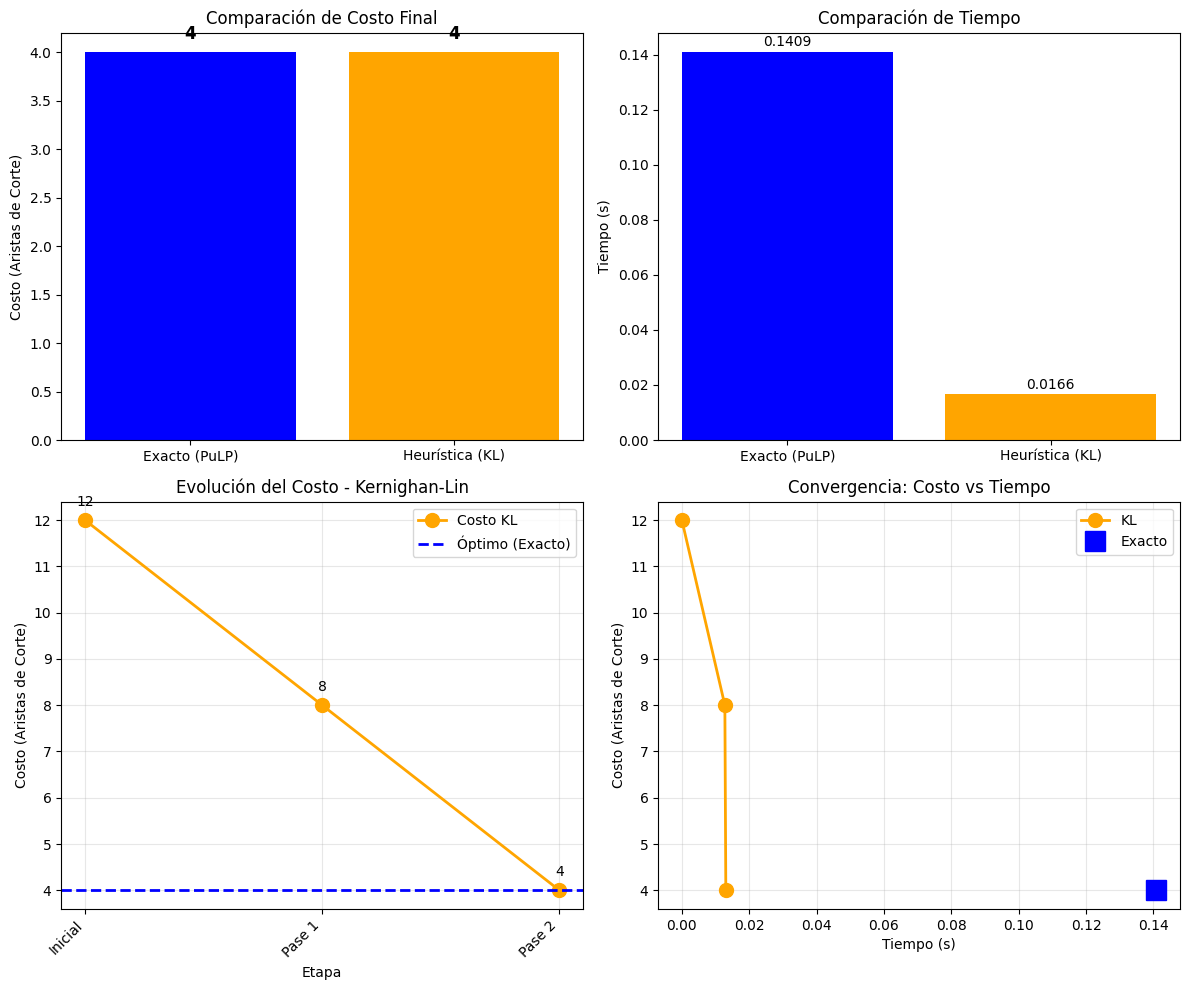

In [140]:

#  GRÁFICOS 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Comparación de costo final
ax1 = axes[0, 0]
metodos = ['Exacto (PuLP)', 'Heurística (KL)']
cortes = [corte_exact, corte_kl]
bars = ax1.bar(metodos, cortes, color=['blue', 'orange'])
ax1.set_ylabel('Costo (Aristas de Corte)')
ax1.set_title('Comparación de Costo Final')
for bar, val in zip(bars, cortes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Gráfico 2: Comparación de tiempo
ax2 = axes[0, 1]
tiempos = [t_exact, t_kl]
bars = ax2.bar(metodos, tiempos, color=['blue', 'orange'])
ax2.set_ylabel('Tiempo (s)')
ax2.set_title('Comparación de Tiempo')
for bar, val in zip(bars, tiempos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Gráfico 3: Evolución del costo por pase (KL)
ax3 = axes[1, 0]
ax3.plot(range(len(historial_costos)), historial_costos, 'o-', color='orange', 
         linewidth=2, markersize=10, label='Costo KL')
ax3.axhline(y=corte_exact, color='blue', linestyle='--', linewidth=2, label='Óptimo (Exacto)')
ax3.set_xlabel('Etapa')
ax3.set_ylabel('Costo (Aristas de Corte)')
ax3.set_title('Evolución del Costo - Kernighan-Lin')
ax3.set_xticks(range(len(historial_etiquetas)))
ax3.set_xticklabels(historial_etiquetas, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)
# Anotar valores
for i, (x, y) in enumerate(zip(range(len(historial_costos)), historial_costos)):
    ax3.annotate(str(y), (x, y), textcoords="offset points", xytext=(0,10), ha='center')

# Gráfico 4: Costo vs Tiempo
ax4 = axes[1, 1]
ax4.plot(historial_tiempos, historial_costos, 'o-', color='orange', 
         linewidth=2, markersize=10, label='KL')
ax4.plot([t_exact], [corte_exact], 's', color='blue', markersize=15, label='Exacto')
ax4.set_xlabel('Tiempo (s)')
ax4.set_ylabel('Costo (Aristas de Corte)')
ax4.set_title('Convergencia: Costo vs Tiempo')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

